In [1]:
# These are the packages that we need for this mapping workflow

import folium
import matplotlib.pyplot as plt
import json
import pathlib
import geopandas as gpd
import pandas as pd
from shapely.geometry import point
from pathlib import Path
import contextily as ctx
from folium.plugins import TimestampedGeoJson
from matplotlib.colors import LinearSegmentedColormap

# Wildfire Mapping in Los Angeles, CA (January 2025)

In [2]:
# Import CSV as DataFrame

# path_LA_Jan25 = Path("/users/tobiasessebier/documents/uzh/GEO876 Spatial Programming/Final Project/FIRMS_LA_Jan25_VIIRS-C2.csv")
df_LA_Jan25 = pd.read_csv("FIRMS_LA_Jan25_VIIRS-C2.csv")

# convert into GeoDataFrame, using the latitude and longitude columns for geometry column in gdf

gdf_LA_Jan25 = gpd.GeoDataFrame(
    df_LA_Jan25, 
    geometry=gpd.points_from_xy(
    df_LA_Jan25["longitude"], df_LA_Jan25["latitude"]), 
    crs="EPSG:4326")

# Create new column Acquired Datetime as datetime64 datatype

gdf_LA_Jan25['Acquiration Time'] = pd.to_datetime(gdf_LA_Jan25['acq_date'] + ' ' + 
                                                  gdf_LA_Jan25['acq_time'].astype(str).str.zfill(4), format='%Y-%m-%d %H%M')

## Functions to classify  
1. Classification of Fire radiative power and Thermal brightness
2. Color and radius definitions of Fire radiative power and Thermal brightness

In [3]:
# as primary proxy, we use fire radiative power as it quantifies the combustion energy of fires
def classify_frp(frp):
    
    if frp <= 10:
        return 1
        
    elif frp > 10 and frp < 50:
        return 2
        
    else: return 3
    # maybe 4 classes as well?

# we use thermal brightness as second proxy for fire intensity as it directly indicates flaming and fire heat,
    # therefore serving as primary indicator for fire detections
def classify_brightness(brightness):
    
    if brightness <= 310:
        return 1
    
    elif brightness > 310 and brightness <= 330:
        return 2
    
    elif brightness > 330 and brightness <= 350:
        return 3
    
    else: return 4

# Color classification
def brightness_color(brightness_classes):
    if brightness_classes == 1:
        return "yellow"
    elif brightness_classes == 2:
        return "orange"
    elif brightness_classes == 3:
        return "red"
    else:
        return "darkred"

# Radius scaling
def frp_radius(frp_classes):
    if frp_classes == 1:
        return 4
    elif frp_classes == 2:
        return 10
    else:
        return 20

## Add columns of classification and color to GeoDataFrame

In [4]:
# new column in GeoDataFrame with categorized Fire radiative power
gdf_LA_Jan25["Frp classes"] = gdf_LA_Jan25["frp"].apply(classify_frp)

# new column in GeoDataFrame with categorized Fire radiative power
gdf_LA_Jan25["Brightness classes"] = gdf_LA_Jan25["brightness"].apply(classify_brightness)

# new column in GeoDataFrame with categorized Brightness colorization
gdf_LA_Jan25["Brightness color"] = gdf_LA_Jan25["Brightness classes"].apply(brightness_color)

# new column in GeoDataFrame with categorized Fire radiative power radius
gdf_LA_Jan25["Frp radius"] = gdf_LA_Jan25["Frp classes"].apply(frp_radius)

## Rename columns to easily understandable titles and check for NaNs

In [5]:
# Create a dictionary that replaces initial column names with new ones
new_names_LA_Jan25 = {
    "brightness": "Thermal brightness",
    "scan": "Pixel width (km)",
    "track": "Pixel height (km)",
    "acq_date": "Date",
    "acq_time": "UTC Time",
    "confidence": "Fire detection confidence",
    "version": "FIRMS Product version",
    "bright_t31": "Thermal Infrared brightness temp",
    "frp": "Fire radiative power",
    "type": "Type of fire"}

# Conduct the renaming by using the 'columns' parameter
gdf_LA_Jan25 = gdf_LA_Jan25.rename(columns=new_names_LA_Jan25)


# Check the data that we have with the newly created column names; look for Nans and -999 missing value placeholders
# This step is only shown to present the final GeoDataFrame structure. Upon checking this .csv, there should not be any Nans or missing values so we proceed.
# the newly created "Brightness color" does not show up in the statistics, as it is a string .dtype!
gdf_LA_Jan25.describe()

,latitude,longitude,Thermal brightness,Pixel width (km),Pixel height (km),UTC Time,FIRMS Product version,Thermal Infrared brightness temp,Fire radiative power,Type of fire,Acquiration Time,Frp classes,Brightness classes,Frp radius
count,2409.000000,2409.000000,2409.000000,2409.000000,2409.000000,2409.000000,2409.0,2409.000000,2409.000000,2409.000000,2409,2409.000000,2409.000000,2409.000000
mean,34.178582,-118.386544,330.732291,0.442565,0.460693,1404.304691,2.0,295.140519,34.518742,0.330843,2025-01-12 09:17:27.820672,1.674139,2.531756,8.830220
min,33.229210,-118.943590,207.930000,0.320000,0.360000,839.000000,2.0,262.600000,0.000000,0.000000,2025-01-01 08:39:00,1.000000,1.000000,4.000000
25%,34.065100,-118.576360,307.920000,0.410000,0.370000,949.000000,2.0,283.680000,1.670000,0.000000,2025-01-08 09:49:00,1.000000,1.000000,4.000000
50%,34.118480,-118.531380,334.340000,0.420000,0.390000,949.000000,2.0,289.370000,8.830000,0.000000,2025-01-09 09:30:00,1.000000,3.000000,4.000000
75%,34.221080,-118.137470,350.660000,0.470000,0.560000,2049.000000,2.0,301.940000,34.850000,0.000000,2025-01-12 10:14:00,2.000000,4.000000,10.000000
max,34.623540,-117.100600,367.000000,0.790000,0.780000,2152.000000,2.0,378.100000,1017.120000,3.000000,2025-01-31 20:37:00,3.000000,4.000000,20.000000
std,0.211954,0.305910,24.644964,0.063973,0.118109,558.923778,0.0,17.555583,65.652142,0.783265,NaN,0.782703,1.157422,6.089435


## Create interactive map, utilizing the GeoDataFrame and its classifications

In [6]:
m = folium.Map(location=[34.1, -118.5],
    # There are two basemaps chosen for this interactive map, the bright CartoDB.Positron and the darker Cartodb dark_matter
        # Try both out by removing the "#" before the "tiles" argument of the one and putting a "#" before the other, and running this cell again!
    tiles="CartoDB.Positron",
    #tiles="Cartodb dark_matter",
    zoom_start=10)

# Create GeoJSON features with loop, iterating through the entire GeoDataFrame
features = []

# this loop iterates through all records in the GeoDataFrame and assigns each feature the properties according to which it will be mapped 
# we save all the information in the "features" list. Each entry is saved as an individual dictionary {} - with all its information in place
for idx, row in gdf_LA_Jan25.iterrows():
    feature = {
        "type": "Feature",
        "geometry": {"type": "Point", "coordinates": [row.geometry.x, row.geometry.y]},
        "properties": {"time": row["Acquiration Time"].strftime("%Y-%m-%d"),
            "style": {
            
            # with the following lines, we call the functions brightness_color and frp_radius that we defined earlier in the functions cell
            # we call them in a way that Pandas can apply the logic to a specific column of the GeoDataFrame as the argument of the function
                "color": row["Brightness color"],
                "fillColor": row["Brightness color"],
                "fillOpacity": 0.5},
            "icon": "circle",
            "iconstyle": {
                "fillColor": row["Brightness color"],
                "fillOpacity": 0.5,
                "stroke": "true",
                "radius": row["Frp radius"],},
            "popup": (
                f"FRP: {row['Fire radiative power']}"
                f"Brightness: {row['Thermal brightness']}")}}

    features.append(feature)

# Add timestamped layer
TimestampedGeoJson(
    {"type": "FeatureCollection",
        "features": features},
  # show points for one day at a time 
    period="P1D",
  # make points disappear after their day is over! Not default in Folium
    duration="P1D",
    add_last_point=False,
    auto_play=False,
    loop=True,
    max_speed=0.4,
    transition_time=400,
    loop_button=True,
    date_options="YYYY-MM-DD",
    time_slider_drag_update=True,).add_to(m)

m

## Mapping most affected counties through a static choropleth map  
1. Read in new California County Geopackage and set GeoDataFrames to EPSG:3857
2. Plot the maps using MatPlotLib

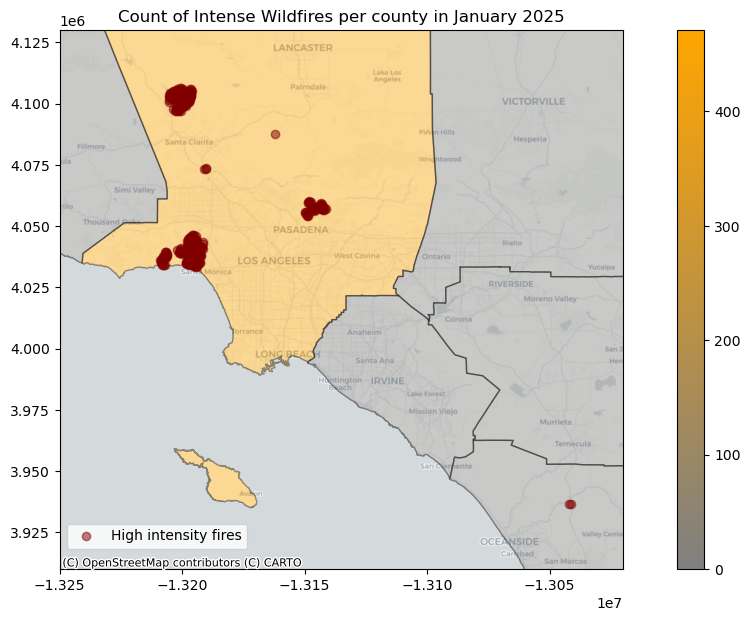

In [7]:
# To visualize the surrounding counties around Los Angeles, CA, we import this GeoPackage containing the Polygons of each county in California
#California_County_gpkg = Path("/users/tobiasessebier/documents/uzh/GEO876 Spatial Programming/Final Project/California_County.gpkg")

# Add the GeoPackage as a new GeoDataFrame
gdf_California_County = gpd.read_file("California_County.gpkg")

# For the visualization with a basemap, we need to convert the GeoDataFrame to EPSG:3857 (Web Mercator) 
gdf_LA_Jan25.to_crs(epsg=3857, inplace=True)

# Like with the LA-GeoDataFrame, we need to convert the County-GeoDataFrame to EPSG:3857 (Web Mercator) as well
gdf_California_County.to_crs(epsg=3857, inplace=True)

# Loop through each row in the cantons dataset
for idx, county_row in gdf_California_County.iterrows():
    # Use the current county's polygon
    county_geom = county_row.geometry

    # Count number of highly intense fires within current county
    # This creates a boolean mask to filter the fire locations within the current county's boundaries
    fires_inside = gdf_LA_Jan25[gdf_LA_Jan25.geometry.within(county_geom)]

    # Check if the county actually contains one or more wildfires
    if not fires_inside.empty:
        # Count number of fires with high frp intensity according to classfication 
        count_fires = (fires_inside["Frp classes"] == 3).sum()

        # This is the step where we fill the number of fires that fall within the county's boundaries into a new column "count_fires"
        gdf_California_County.at[idx, "count_fires"] = count_fires

# New plot showing a choropleth map with counties around Los Angeles and their respective number of intense fires
fig, ax = plt.subplots(figsize=(14, 7))

# create custom colormap because we want it to highlight intensily hit counties
custom_cmap = LinearSegmentedColormap.from_list("gray_to_red", ["gray", "orange"])

# Add the County GeoDataFrame as the second layer, make it transparent, show the boundaries of each county
# and visualize the number of intense fires per county with the newly customized color scheme
gdf_California_County.plot(ax=ax, 
    zorder=2,  
    alpha=0.4,
    edgecolor="black", 
    column="count_fires",
    cmap=custom_cmap,
    legend=True)

# Add the County GeoDataFrame as the third layer
gdf_LA_Jan25[gdf_LA_Jan25["Frp classes"] == 3].plot(ax=ax, 
    zorder=3,
    alpha=0.5, 
    color="maroon",
    label="High intensity fires")

# add basemap from Contextily, and set it as the lowest layer of the map frame
# we have to add the basemap AFTER the GeoDataFrames, as contextility would otherwise block the transparency correction of the GeoDataFrames!
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Positron, zoom=9, zorder=1)
# Option to choose dark basemap again, if desired, by switching out the "#"
# ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.DarkMatter, zoom=9, zorder=1)

# This is the Frame that we need for our research area in EPSG:3857. Since it proved useful to remember which CRS we referenced, we indicate the number
# MatPlotLib would otherwise choose the Bounding Box of the entire state of California as map frame because the Geopackage shows the whole state.
extent_epsg3857 = [-13250000, -13020000, 3910000, 4130000]

# add title of map
ax.set_title("Count of Intense Wildfires per county in January 2025")

# add a legend for the points, and push it slightly up, as it would cover the service layer credits otherwise
ax.legend(loc="lower left", bbox_to_anchor=(0.0, 0.025))

# set the extent to the map frame from which we know that it fits to our research area
ax.set_xlim([extent_epsg3857[0],  extent_epsg3857[1]])
ax.set_ylim([extent_epsg3857[2],  extent_epsg3857[3]])

plt.show()

# Save map frame to our local working directory if needed
# fig.savefig("./Map_Wildfires_Counties_2025.png", dpi=300, bbox_inches="tight")